In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, classification_report
import joblib

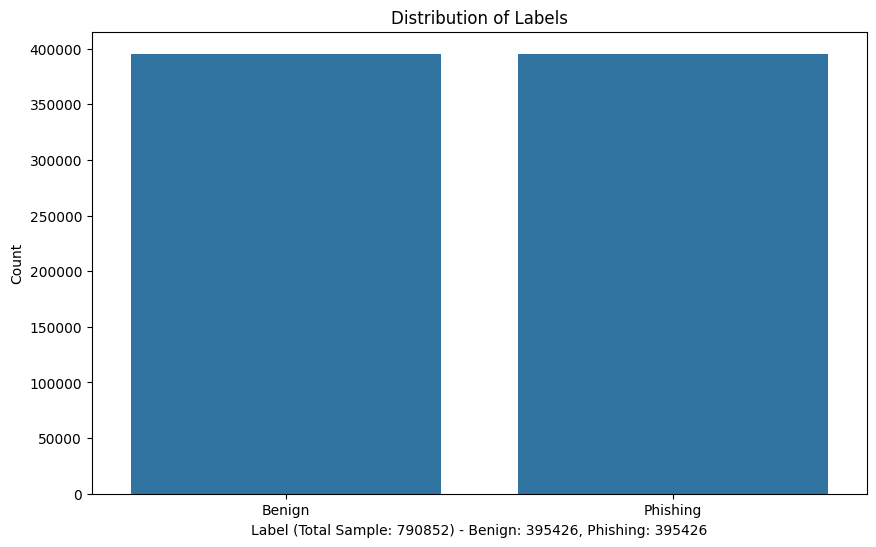

In [2]:
# Distribute Label Studio via PyPI
df_test = pd.read_csv('data/processed/test.csv') 
df_train = pd.read_csv('data/processed/train.csv')
df = pd.merge(df_test, df_train, how='outer')
total_rows = len(df)
label_counts = df['label'].value_counts().sort_index()  # 0 then 1
benign_count = label_counts.get(0, 0)
phishing_count = label_counts.get(1, 0)
plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=df)
plt.title('Distribution of Labels')
plt.xlabel('Label (Total Sample: {total_rows}) - Benign: {benign_count}, Phishing: {phishing_count}'.format(
    total_rows=total_rows, benign_count=benign_count, phishing_count=phishing_count))
plt.ylabel('Count')
plt.xticks([0, 1], ['Benign', 'Phishing'])
plt.show()

In [ ]:
import pandas as pd
from extract_features import extract_features
from tqdm import tqdm

# df = pd.read_csv("data/raw/full_dataset.csv")   # YOUR original URL dataset
df_train = pd.read_csv('data/processed/train.csv')
urls = df_train["url"]

new_rows = []

for u, label in tqdm(zip(df_train["url"], df_train["label"]), total=len(df_train)):
    feats = extract_features(u)
    feats["label"] = label
    new_rows.append(feats)


new_df = pd.DataFrame(new_rows)
new_df.to_csv("data/processed/train_rebuilt.csv", index=False)

print("✅ New dataset built with updated extract_features()")


In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt



train_df = pd.read_csv("data/processed/train.csv")
rf_cal = joblib.load("model/rf_calibrated.pkl")

rf = rf_cal.calibrated_classifiers_[0].estimator
feat_name = train_df.drop(columns=["label"], errors="ignore").columns.tolist()
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feat_name,
    "importance": importances
}).sort_values("importance", ascending=False)

print("✅ Found", len(rf_cal.calibrated_classifiers_), "calibrated folds")
print("✅ Using fold 0 RandomForest model")
print("✅ Number of features:", rf.n_features_in_)
print("\n=== Top Feature Importances ===")
print(feature_importance_df.head(20))

plt.figure(figsize=(10,6))
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importances (Leak-free RF Model)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

df = pd.read_csv("data/processed/train_rebuilt.csv")

# Convert new extractor columns back to old trained-model columns
df["domain_age_days"] = df["domain_age_days_x"]
df["popularity_score"] = df["popularity_score_x"]
df["is_top1m"] = df["is_top1m_x"]
df["is_majestic"] = df["is_majestic_x"]
df["trust_rank_norm"] = df["trust_rank_norm_x"]

# Remove the extra duplicate columns
df = df.drop(columns=[
    "domain_age_days_x", "domain_age_days_y",
    "popularity_score_x", "popularity_score_y",
    "is_top1m_x", "is_top1m_y",
    "is_majestic_x", "is_majestic_y",
    "trust_rank_norm_x", "trust_rank_norm_y"
])

df.to_csv("data/processed/train_fixed.csv", index=False)

print("✅ train_fixed.csv created with correct feature names for the model.")


✅ train_fixed.csv created with correct feature names for the model.


In [ ]:
df = pd.read_csv("data/processed/train_fixed.csv")
df.columns


In [5]:
import pandas as pd

df = pd.read_csv("data/processed/train_rebuilt.csv")
print(df.columns.tolist())
print(len(df.columns.tolist()))
tot = len(df)
print(tot)

['url', 'url_length', 'domain_length', 'num_dots', 'num_hyphens', 'num_at', 'num_question', 'num_equals', 'num_digits', 'num_subdirs', 'has_https', 'tld', 'entropy', 'is_shortened', 'has_ip', 'ssl_days_valid', 'has_dns_record', 'tld_enc', 'domain_age_days_x', 'domain_age_days_y', 'popularity_score_x', 'popularity_score_y', 'is_top1m_x', 'is_top1m_y', 'is_majestic_x', 'is_majestic_y', 'trust_rank_norm_x', 'trust_rank_norm_y', 'label']
29
632681


In [9]:
rf = joblib.load("model/new_rf_calibrated.pkl")
print(rf.feature_names_in_)

['url_length' 'domain_length' 'num_dots' 'num_hyphens' 'num_at'
 'num_question' 'num_equals' 'num_digits' 'num_subdirs' 'has_https'
 'entropy' 'is_shortened' 'has_ip' 'ssl_days_valid' 'has_dns_record'
 'tld_enc' 'domain_age_days_x' 'domain_age_days_y' 'popularity_score_x'
 'popularity_score_y' 'is_top1m_x' 'is_top1m_y' 'is_majestic_x'
 'is_majestic_y' 'trust_rank_norm_x' 'trust_rank_norm_y']


In [2]:
import joblib
rf = joblib.load("model/rf_base.pkl")
print(rf.feature_names_in_)

['url_length' 'domain_length' 'num_dots' 'num_hyphens' 'num_at'
 'num_question' 'num_equals' 'num_digits' 'num_subdirs' 'has_https'
 'entropy' 'is_shortened' 'has_ip' 'ssl_days_valid' 'has_dns_record'
 'tld_enc' 'domain_age_days_x' 'domain_age_days_y' 'popularity_score_x'
 'popularity_score_y' 'is_top1m_x' 'is_top1m_y' 'is_majestic_x'
 'is_majestic_y' 'trust_rank_norm_x' 'trust_rank_norm_y']


In [3]:
rf_calibrated = joblib.load("model/rf_calibrated.pkl")
print(rf_calibrated.feature_names_in_)

['url_length' 'domain_length' 'num_dots' 'num_hyphens' 'num_at'
 'num_question' 'num_equals' 'num_digits' 'num_subdirs' 'has_https'
 'entropy' 'is_shortened' 'has_ip' 'ssl_days_valid' 'has_dns_record'
 'domain_age_days_x' 'popularity_score_x' 'is_top1m_x' 'is_majestic_x'
 'trust_rank_norm_x' 'domain_age_days_y' 'popularity_score_y' 'is_top1m_y'
 'is_majestic_y' 'trust_rank_norm_y' 'domain_age_days' 'tld_enc']


In [4]:
# Generate Confusion Matrix, data balancing for all models
# ===============================================================
# metrics_confusion_and_balance.py
# Compute TP/TN/FP/FN + confusion matrix + class balance
# For RF, LGBM, XGB, CNN_feature, FFNN_feature, LSTM_feature
# ===============================================================

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv("data/processed/train_rebuilt.csv").fillna(0)

X = df.drop(columns=["url", "tld", "label"], errors="ignore")
y = df["label"].values
urls = df["url"]

X_np = X.values  # classical models need numpy

# -------------------------------
# LOAD CLASSICAL MODELS
# -------------------------------
rf = joblib.load("model/rf_base.pkl")
lgbm = joblib.load("model/lgbm_base.pkl")
xgb = joblib.load("model/xgb_base.pkl")

# -------------------------------
# LOAD DEEP MODELS (Lightning)
# -------------------------------
from phishin_train_cnn import LightningCNN, URLDataset
from phishin_train_ffnn import LightningFFNN
from phishin_nlp_lstm import LightningLSTM  # <-- ADD THIS IMPORT

DEVICE = "cpu"
MAX_LEN = 200

def predict_lstm(model, urls):
    preds = []
    for url in urls:
        s = str(url)[:200].ljust(200)
        x = torch.tensor([min(ord(c), 127) for c in s], dtype=torch.long).unsqueeze(0)
        with torch.no_grad():
            torch.backends.cudnn.enabled = False
            out = model(x.cpu())
            torch.backends.cudnn.enabled = True
        preds.append(float(torch.sigmoid(out).item()))
    return np.array(preds)


CNN_MODEL = LightningCNN.load_from_checkpoint(
    "models/cnn_lightning.ckpt", map_location=DEVICE, lr=1e-3
).eval()

FFNN_MODEL = LightningFFNN.load_from_checkpoint(
    "models/ffnn_lightning.ckpt", map_location=DEVICE, lr=1e-3
).eval()

LSTM_MODEL = LightningLSTM.load_from_checkpoint(
    "models/lstm_lightning.ckpt", map_location=DEVICE, lr=1e-3
).eval()

# -----------------------------------------
# Helper: Deep Model Prediction
# -----------------------------------------
def predict_dl(model, urls):
    preds = []
    ds = URLDataset(urls, pd.Series(y), max_len=MAX_LEN)  # FIXED
    with torch.no_grad():
        for x, _ in ds:
            p = torch.sigmoid(model(x.unsqueeze(0))).item()
            preds.append(p)
    return np.array(preds)



# -----------------------------------------
# CLASSICAL MODEL PREDICTIONS
# -----------------------------------------
pred_rf = rf.predict_proba(X_np)[:, 1]
pred_lgbm = lgbm.predict_proba(X_np)[:, 1]
pred_xgb = xgb.predict_proba(X_np)[:, 1]

# -----------------------------------------
# DEEP MODELS PREDICTIONS
# -----------------------------------------
pred_cnn = predict_dl(CNN_MODEL, urls)
pred_ffnn = predict_dl(FFNN_MODEL, urls)
pred_lstm = predict_lstm(LSTM_MODEL, urls)


# Convert prob → class
def binarize(p): return (p >= 0.5).astype(int)

models = {
    "RF": pred_rf,
    "LGBM": pred_lgbm,
    "XGB": pred_xgb,
    "CNN_feature": pred_cnn,
    "FFNN_feature": pred_ffnn,
    "LSTM_feature": pred_lstm,
}

results = []

# ====================================================
# Compute metrics for each model
# ====================================================
for name, probs in models.items():
    y_pred = binarize(probs)

    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "model": name,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
    })

    print(f"\n📊 {name} Confusion Matrix")
    print(cm)

    # Confusion Matrix Heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Phishing"],
                yticklabels=["Benign", "Phishing"])
    plt.title(f"{name} – Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"plots/{name}_confusion_matrix.png", dpi=300)
    plt.close()

    # Prediction Pie Chart
    plt.figure(figsize=(4,4))
    plt.pie([tn+fp, tp+fn],
            labels=["Benign", "Phishing"],
            autopct="%1.1f%%",
            colors=["skyblue", "salmon"])
    plt.title(f"{name} – Prediction Class Distribution")
    plt.tight_layout()
    plt.savefig(f"plots/{name}_prediction_distribution.png", dpi=300)
    plt.close()


# ====================================================
# SAVE CSV
# ====================================================
df_res = pd.DataFrame(results)
df_res.to_csv("model/classical_dl_confusion_metrics.csv", index=False)

print("\n✅ Saved → model/classical_dl_confusion_metrics.csv")
print(df_res)

# ====================================================
# PIE CHART — Dataset Balance
# ====================================================
plt.figure(figsize=(4,4))
plt.pie(df["label"].value_counts().values,
        labels=["Benign", "Phishing"],
        autopct="%1.1f%%",
        colors=["green", "red"])
plt.title("Dataset Balance (Benign vs Phishing)")
plt.tight_layout()
plt.savefig("plots/dataset_balance.png", dpi=300)
plt.close()

print("\n🔥 Complete — confusion matrices, pie charts, and CSV generated.")


c:\Users\tohee\miniconda3\envs\pytorch_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\tohee\miniconda3\envs\pytorch_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📊 RF Confusion Matrix
[[300934  15406]
 [  8651 307690]]

📊 LGBM Confusion Matrix
[[295772  20568]
 [ 14289 302052]]

📊 XGB Confusion Matrix
[[294549  21791]
 [ 15458 300883]]

📊 CNN_feature Confusion Matrix
[[307220   9120]
 [  9686 306655]]

📊 FFNN_feature Confusion Matrix
[[282915  33425]
 [ 19355 296986]]

📊 LSTM_feature Confusion Matrix
[[309356   6984]
 [  3571 312770]]

✅ Saved → model/classical_dl_confusion_metrics.csv
          model      TP      TN     FP     FN  accuracy  precision    recall  \
0            RF  307690  300934  15406   8651  0.961976   0.952318  0.972653   
1          LGBM  302052  295772  20568  14289  0.944906   0.936247  0.954830   
2           XGB  300883  294549  21791  15458  0.941125   0.932467  0.951135   
3   CNN_feature  306655  307220   9120   9686  0.970276   0.971119  0.969381   
4  FFNN_feature  296986  282915  33425  19355  0.916577   0.898838  0.938816   
5  LSTM_feature  312770  309356   6984   3571  0.983317   0.978158  0.988712   

       

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Use whichever dataset is correct for RF:
df = pd.read_csv("data/processed/train.csv")   # RF matches this schema

# Drop non-numeric columns
df_num = df.select_dtypes(include=['number'])

plt.figure(figsize=(20, 14))
sns.heatmap(
    df_num.corr(),
    annot=False,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap (Numeric Features vs Label)", fontsize=16)
plt.tight_layout()
plt.show()


In [5]:
# Generate all correlation heatmaps for numeric features
# ============================================================
# correlation_analysis.py
# Generates Pearson, Spearman, and automatic interpretation tables
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# ------------------------------------------------------------
# Load dataset (must match RF training schema)
# ------------------------------------------------------------
df = pd.read_csv("data/processed/train.csv").fillna(0)

# Keep numeric columns only
df_num = df.select_dtypes(include=["number"])

os.makedirs("plots", exist_ok=True)
os.makedirs("model", exist_ok=True)

# ------------------------------------------------------------
# 1. Pearson Correlation
# ------------------------------------------------------------
pearson_corr = df_num.corr(method="pearson")

plt.figure(figsize=(20, 14))
sns.heatmap(
    pearson_corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pearson Correlation Heatmap (Numeric Features vs Label)", fontsize=16)
plt.tight_layout()
plt.savefig("plots/pearson_heatmap.png", dpi=300)
plt.close()

# ------------------------------------------------------------
# 2. Spearman Correlation
# ------------------------------------------------------------
spearman_corr = df_num.corr(method="spearman")

plt.figure(figsize=(20, 14))
sns.heatmap(
    spearman_corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
plt.title("Spearman Correlation Heatmap (Numeric Features vs Label)", fontsize=16)
plt.tight_layout()
plt.savefig("plots/spearman_heatmap.png", dpi=300)
plt.close()

# ------------------------------------------------------------
# 3. Top correlated features with LABEL (Pearson)
# ------------------------------------------------------------
pearson_top = (
    pearson_corr["label"]
    .abs()
    .sort_values(ascending=False)
    .drop("label")
    .head(10)
)

pearson_top_df = pd.DataFrame({
    "feature": pearson_top.index,
    "pearson_corr": pearson_top.values
})
pearson_top_df.to_csv("model/pearson_top10.csv", index=False)

print("\n📌 Top 10 Pearson-correlated features:")
print(pearson_top_df)

# ------------------------------------------------------------
# 4. Top correlated features with LABEL (Spearman)
# ------------------------------------------------------------
spearman_top = (
    spearman_corr["label"]
    .abs()
    .sort_values(ascending=False)
    .drop("label")
    .head(10)
)

spearman_top_df = pd.DataFrame({
    "feature": spearman_top.index,
    "spearman_corr": spearman_top.values
})
spearman_top_df.to_csv("model/spearman_top10.csv", index=False)

print("\n📌 Top 10 Spearman-correlated features:")
print(spearman_top_df)

# ------------------------------------------------------------
# 5. Automatic Interpretation Table (Your dissertation format)
# ------------------------------------------------------------

def interpret_feature(feature, corr_value):
    """Returns human-readable interpretation."""
    if "top1m" in feature:
        return ("Negative", "Phishing URLs rarely appear in Alexa Top1M.")
    if "majestic" in feature:
        return ("Negative", "Phishing domains lack Majestic trust ranking.")
    if "popularity" in feature:
        return ("Negative", "Low domain popularity indicates phishing behaviour.")
    if "trust_rank" in feature:
        return ("Negative", "Low trust rank is common in phishing domains.")
    if "entropy" in feature:
        return ("Positive", "High randomness in URL path is suspicious.")
    if "has_ip" in feature:
        return ("Positive", "IP-based URLs are commonly used by phishing attackers.")
    if "ssl" in feature:
        return ("Negative" if corr_value < 0 else "Positive",
                "Very short or invalid SSL validity is suspicious.")
    if "domain_age" in feature:
        return ("Negative", "Young domains are strongly associated with phishing.")
    return ("Mixed", "Feature shows correlation but requires deeper analysis.")

interpret_rows = []
for feat, corr in pearson_top.items():
    relation, meaning = interpret_feature(feat, corr)
    interpret_rows.append([feat, relation, meaning])

interpret_df = pd.DataFrame(
    interpret_rows,
    columns=["Feature", "Relationship", "Meaning"]
)

interpret_df.to_csv("model/feature_interpretation_table.csv", index=False)

print("\n📘 Interpretation Table:")
print(interpret_df)

print("\n🎉 All correlation plots + tables generated.")
print("Saved to /plots and /model folders.")



📌 Top 10 Pearson-correlated features:
         feature  pearson_corr
0      has_https      0.520154
1       num_dots      0.431311
2    num_subdirs      0.221471
3     num_equals      0.218316
4   num_question      0.194795
5     url_length      0.177929
6     num_digits      0.078783
7  domain_length      0.047369
8         num_at      0.010854
9    num_hyphens      0.008496

📌 Top 10 Spearman-correlated features:
         feature  spearman_corr
0       num_dots       0.598274
1      has_https       0.520154
2     url_length       0.389986
3    num_subdirs       0.308763
4     num_equals       0.215007
5   num_question       0.205060
6     num_digits       0.186209
7  domain_length       0.149096
8    num_hyphens       0.071170
9         num_at       0.013896

📘 Interpretation Table:
         Feature Relationship  \
0      has_https        Mixed   
1       num_dots        Mixed   
2    num_subdirs        Mixed   
3     num_equals        Mixed   
4   num_question        Mixed   
5    